# 3 · Tick Data: VWAP, TWAP, and Sampling in "Volume Time"

*Module 1 — Market Microstructure*

Turning a raw stream of individual trades into (a) a benchmark for judging execution quality, and (b) a cleaner way to sample data for everything downstream in this course.

## 1. Motivation

A pension fund's desk needs to buy 500,000 shares over the course of a trading day. At the end of the day, how do we judge whether they did a good job? "They paid €50.10 on average" means nothing on its own — was the stock trending up all day anyway? The industry-standard answer is to compare the execution to the **VWAP** (volume-weighted average price) achieved by the *entire market* that day: if everyone who traded that stock, combined, averaged €50.08, and the desk achieved €50.10, they underperformed the market by 2 cents a share. This single benchmark is used to judge trillions of dollars of institutional execution every year.

To compute it properly — and to build any serious quantitative model afterward — we need to work with **tick data**: the record of every individual trade, not just a daily or hourly summary. This notebook shows how to go from that raw firehose of ticks to a usable, well-behaved dataset.

## 2. Intuition

**VWAP** answers: "what price did the market pay, on average, weighting every share traded equally?" A period with heavy trading counts a lot; a quiet period counts little. **TWAP** answers a different question: "what was the average price, sampled equally across time, regardless of how much volume happened when?" A quiet lunchtime hour counts exactly as much as a frantic first ten minutes.

Neither is "more correct" — they answer different questions. If you want to blend into the day's natural trading pattern (so your own trading doesn't stand out and move the price), you trade like VWAP: more when the market is busy, less when it's quiet. If you want predictable, steady participation regardless of market activity, you trade like TWAP.

There is a second, more subtle idea in this notebook. So far, and in most introductory treatments, market data means "a bar every minute" or "a bar every day" — sampling by the **clock**. But the clock is a strange thing to sample by: the first and last few minutes of a trading day are frantic, lunchtime is dead, and this pattern repeats every single day. A clock-based bar during the frantic open might contain 200 trades; the same-length bar at lunch might contain three. This means clock-based (time) bars have wildly uneven statistical properties from bar to bar. The fix is almost embarrassingly simple once you see it: don't sample every fixed *time*, sample every fixed amount of **volume**, or every fixed amount of **money traded**. A quiet period produces bars slowly; a busy period produces them quickly — the sampling clock speeds up and slows down with the market itself.

## 3. Theory

### 3.1 VWAP and TWAP

Let tick data over some window be the sequence of individual trades $(t_i, p_i, q_i)_{i=1}^N$: timestamp, price, and size. The **volume-weighted average price** is

$$
VWAP = \frac{\sum_{i=1}^N p_i\, q_i}{\sum_{i=1}^N q_i} ,
$$

literally total money exchanged divided by total shares exchanged — the average price *per share traded*, not per unit of time. The **time-weighted average price**, by contrast, partitions the window into $n$ equal sub-intervals and averages a representative price from each, with no reference to how much volume happened in it:

$$
TWAP = \frac{1}{n}\sum_{j=1}^n \bar p_{(j)}, \qquad \bar p_{(j)} = \text{average trade price in sub-interval } j .
$$

An execution algorithm that trades in proportion to expected volume in each sub-period is, by construction, targeting VWAP. One that slices an order into $n$ equal pieces, one per sub-interval, is targeting TWAP.

### 3.2 Bars as stopping times

A "bar" (an OHLCV summary: open, high, low, close, volume) is normally built by fixing a *time* grid: one bar every 5 minutes, say. We can describe this more formally, in language that connects directly to your probability background, as a sequence of **stopping times** $\tau_1 < \tau_2 < \dots$ at which we "close" the current bar and start a new one. A time bar uses the trivial, deterministic rule $\tau_k = k\cdot\Delta$ for a fixed $\Delta$ (e.g., 5 minutes) — it does not look at the data at all to decide when to stop.

A **volume bar** instead uses the data itself. Fix a threshold $V^\ast$, and define

$$
\tau_k = \min\Big\{ t \;:\; \textstyle\sum_{i:\, \tau_{k-1} < t_i \le t} q_i \ge V^\ast \Big\},
$$

i.e., close the bar the moment cumulative traded volume since the last bar reaches $V^\ast$. A **dollar bar** is identical but thresholds cumulative *dollar* volume $\sum p_i q_i$ instead of share volume.

### 3.3 Why bother?

Two concrete reasons, beyond the philosophical appeal of "sampling in the market's own clock":

1. **More uniform statistical behavior.** Because time bars force the same time budget onto both frantic and dead periods, the number of trades — and hence the information content — packed into each bar varies enormously. Volume and dollar bars instead force roughly the same *amount of trading* into each bar, which empirical work (see López de Prado, *Advances in Financial Machine Learning*, 2018, Ch. 2) finds produces returns closer to independent and identically distributed — a much friendlier input for the statistical and machine-learning methods used throughout the rest of this course. We check this claim directly on our own simulated data below, rather than simply asserting it.
2. **Dollar bars are robust to price-level changes.** A stock that undergoes a 4-for-1 split, or simply trends from €20 to €200 over a decade, needs a completely different volume threshold before and after to represent "the same amount of activity" — 10,000 shares of a €20 stock and 10,000 shares of a €200 stock are not comparable. A dollar-volume threshold is largely immune to this, since it already accounts for the price level.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(7)

## 4. Implementation

### 4.1 Simulating a day of tick data

We simulate a single trading day (390 minutes, matching a standard 6.5-hour session) of individual trades. Two realistic features are built in on purpose, because they drive everything that follows:

- **A U-shaped intensity profile**: trades arrive faster near the open and close, and more slowly around midday — the best-documented pattern in intraday trading activity.
- **A slowly-drifting order-flow imbalance**: rather than every trade's direction being an independent coin flip, we let a latent, mean-reverting process determine the *probability* of a buy vs. a sell at each point in time, so buying and selling pressure clusters in bursts, and — via the same mechanism used in Notebook 2 — that imbalance is what actually moves the price.

In [2]:
def simulate_trading_day(n_minutes=390, base_rate=6.0, lam_price=1.2e-6, start_price=50.00, seed=0):
    """
    Simulate one trading day of tick-by-tick trades.
    Returns a DataFrame with columns: t (minutes since open), price, size, sign, dollar.
    """
    local_rng = np.random.default_rng(seed)
    minutes = np.arange(n_minutes)

    # U-shaped arrival intensity: high near the open (m=0) and close (m=n_minutes),
    # low around midday -- a sine-based shape that needs no extra parameters.
    intensity = base_rate * (1.8 - 1.4 * np.sin(np.pi * minutes / n_minutes))

    # Latent order-flow imbalance: mean-reverting AR(1), clipped to stay well-behaved.
    # imbalance > 0 means buy pressure is currently more likely than sell pressure.
    imbalance = np.zeros(n_minutes)
    for m in range(1, n_minutes):
        imbalance[m] = 0.98 * imbalance[m - 1] + local_rng.normal(0, 0.05)
    imbalance = np.clip(imbalance, -0.9, 0.9)

    trades = []
    price = start_price
    for m in range(n_minutes):
        n_trades_this_min = local_rng.poisson(intensity[m])
        for _ in range(n_trades_this_min):
            t = m + local_rng.random()                                    # exact timestamp within the minute
            sign = 1 if local_rng.random() < (1 + imbalance[m]) / 2 else -1
            size = max(int(local_rng.lognormal(mean=4.3, sigma=0.9)), 1)   # heavy right-tailed trade sizes
            price += lam_price * sign * size * price + local_rng.normal(0, 0.0003)
            trades.append((t, price, size, sign))

    df = pd.DataFrame(trades, columns=['t', 'price', 'size', 'sign']).sort_values('t').reset_index(drop=True)
    df['dollar'] = df['price'] * df['size']
    return df, intensity

ticks, intensity_profile = simulate_trading_day(seed=7)
print(f"Simulated {len(ticks)} individual trades over the day.")
print(f"Total volume: {ticks['size'].sum():,} shares  |  Total dollar volume: EUR {ticks['dollar'].sum():,.0f}")
ticks.head()

Simulated 2164 individual trades over the day.
Total volume: 232,395 shares  |  Total dollar volume: EUR 11,132,818


,t,price,size,sign,dollar
0,0.065315,49.979000,62,-1,3098.698031
1,0.155130,49.987659,181,-1,9047.766200
2,0.195549,49.987200,163,-1,8147.913541
3,0.415088,49.979213,13,-1,649.729768
4,0.468670,49.979845,16,1,799.677524


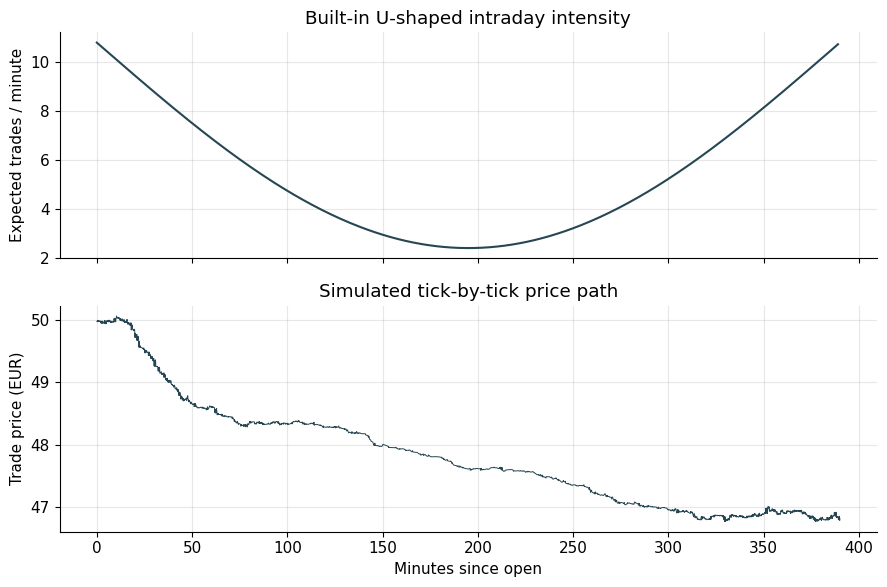

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(np.arange(390), intensity_profile, color='#264653')
axes[0].set_ylabel('Expected trades / minute')
axes[0].set_title('Built-in U-shaped intraday intensity')

axes[1].plot(ticks['t'], ticks['price'], color='#264653', linewidth=0.7)
axes[1].set_ylabel('Trade price (EUR)')
axes[1].set_xlabel('Minutes since open')
axes[1].set_title('Simulated tick-by-tick price path')

plt.tight_layout()
plt.show()

### 4.2 VWAP and TWAP, coded directly from Section 3.1

In [4]:
def compute_vwap(df):
    """Volume-weighted average price, exactly as defined in Section 3.1."""
    return (df['price'] * df['size']).sum() / df['size'].sum()

def compute_twap(df, n_buckets=390):
    """Time-weighted average price: equal-weight average of the mean price in each of n equal time buckets."""
    edges = np.linspace(df['t'].min(), df['t'].max(), n_buckets + 1)
    bucket = pd.cut(df['t'], edges, labels=False, include_lowest=True)
    bucket_prices = df.groupby(bucket)['price'].mean()
    return bucket_prices.mean()

day_vwap = compute_vwap(ticks)
day_twap = compute_twap(ticks, n_buckets=390)
print(f"Full-day VWAP: {day_vwap:.4f}")
print(f"Full-day TWAP: {day_twap:.4f}")
print(f"Difference:    {(day_vwap-day_twap)*1e4/day_vwap:.2f} bps -- "
      f"the two differ whenever volume and price level are correlated over the day.")

Full-day VWAP: 47.9047
Full-day TWAP: 47.8169
Difference:    18.34 bps -- the two differ whenever volume and price level are correlated over the day.


### 4.3 Building time, volume, and dollar bars

Each function below is a direct implementation of the stopping-time definitions in Section 3.2.

In [5]:
def make_time_bars(df, bar_minutes):
    """Time bars: close a bar every fixed number of minutes, regardless of activity."""
    d = df.copy()
    d['bar'] = (d['t'] // bar_minutes).astype(int)
    bars = d.groupby('bar').agg(t_end=('t', 'last'), open=('price', 'first'), high=('price', 'max'),
                                 low=('price', 'min'), close=('price', 'last'),
                                 volume=('size', 'sum'), dollar=('dollar', 'sum'), n_trades=('price', 'count'))
    return bars.reset_index(drop=True)

def _threshold_bars(df, cum_col, threshold):
    """Shared logic for volume and dollar bars: close a bar once cum_col's running sum hits threshold."""
    d = df.sort_values('t').reset_index(drop=True)
    bars, cum, start = [], 0.0, 0
    for i in range(len(d)):
        cum += d[cum_col].iloc[i]
        if cum >= threshold:
            chunk = d.iloc[start:i + 1]
            bars.append({'t_end': chunk['t'].iloc[-1], 'open': chunk['price'].iloc[0],
                         'high': chunk['price'].max(), 'low': chunk['price'].min(),
                         'close': chunk['price'].iloc[-1], 'volume': chunk['size'].sum(),
                         'dollar': chunk['dollar'].sum(), 'n_trades': len(chunk)})
            start, cum = i + 1, 0.0
    return pd.DataFrame(bars)

def make_volume_bars(df, vol_threshold):
    return _threshold_bars(df, 'size', vol_threshold)

def make_dollar_bars(df, dollar_threshold):
    return _threshold_bars(df, 'dollar', dollar_threshold)

# Thresholds chosen so all three methods produce a comparable NUMBER of bars,
# for a fair comparison below.
time_bars   = make_time_bars(ticks, bar_minutes=2)
volume_bars = make_volume_bars(ticks, vol_threshold=1200)
dollar_bars = make_dollar_bars(ticks, dollar_threshold=57000)

print(f"Time bars:   {len(time_bars)}")
print(f"Volume bars: {len(volume_bars)}")
print(f"Dollar bars: {len(dollar_bars)}")

Time bars:   195
Volume bars: 177
Dollar bars: 179


## 5. Worked example

### 5.1 Judging an execution against the VWAP benchmark

We evaluate two hypothetical execution styles for a large buy order, spread across 26 fifteen-minute windows: one that buys an **equal number of shares in every window** (a TWAP-style algorithm) and one that buys **shares in proportion to that window's actual traded volume** (a VWAP-style algorithm). For each, the achieved price in a window is approximated by that window's own VWAP.

In [6]:
window_min = 15
ticks['window'] = (ticks['t'] // window_min).astype(int)
window_stats = ticks.groupby('window').apply(
    lambda g: pd.Series({'vwap': compute_vwap(g), 'volume': g['size'].sum()}),
    include_groups=False
)

# TWAP-style: equal shares per window -> achieved price is the simple average of window VWAPs
twap_style_price = window_stats['vwap'].mean()

# VWAP-style: shares proportional to each window's volume -> achieved price is volume-weighted
vwap_style_price = (window_stats['vwap'] * window_stats['volume']).sum() / window_stats['volume'].sum()

print(f"Full-day VWAP benchmark:      {day_vwap:.4f}")
print(f"TWAP-style execution price:   {twap_style_price:.4f}   "
      f"({(twap_style_price-day_vwap)/day_vwap*1e4:+.2f} bps vs. VWAP benchmark)")
print(f"VWAP-style execution price:   {vwap_style_price:.4f}   "
      f"({(vwap_style_price-day_vwap)/day_vwap*1e4:+.2f} bps vs. VWAP benchmark)")

Full-day VWAP benchmark:      47.9047
TWAP-style execution price:   47.8205   (-17.58 bps vs. VWAP benchmark)
VWAP-style execution price:   47.9047   (-0.00 bps vs. VWAP benchmark)


The VWAP-style execution lands almost exactly on the VWAP benchmark — not a coincidence, but a direct consequence of trading in proportion to volume, which is the definition of VWAP. The TWAP-style execution, which ignores where the day's volume actually was, shows a real (if modest, in this simulation) deviation. In practice, this gap is exactly what an execution desk's "VWAP slippage" report is measuring, and it is why algorithms explicitly targeting VWAP exist as a standard offering at every broker.

### 5.2 Do volume bars really look more like i.i.d. draws?

In [7]:
def bar_log_returns(bars):
    return np.log(bars['close']).diff().dropna()

r_time   = bar_log_returns(time_bars)
r_volume = bar_log_returns(volume_bars)
r_dollar = bar_log_returns(dollar_bars)

summary = pd.DataFrame({
    'n_bars':  [len(r_time), len(r_volume), len(r_dollar)],
    'skew':    [stats.skew(r_time), stats.skew(r_volume), stats.skew(r_dollar)],
    'exc_kurt': [stats.kurtosis(r_time), stats.kurtosis(r_volume), stats.kurtosis(r_dollar)],
    'jarque_bera_stat': [stats.jarque_bera(r_time)[0], stats.jarque_bera(r_volume)[0], stats.jarque_bera(r_dollar)[0]],
    'jarque_bera_pval': [stats.jarque_bera(r_time)[1], stats.jarque_bera(r_volume)[1], stats.jarque_bera(r_dollar)[1]],
}, index=['time bars', 'volume bars', 'dollar bars'])
summary

,n_bars,skew,exc_kurt,jarque_bera_stat,jarque_bera_pval
time bars,194,-0.909232,2.005197,59.231648,1.374077e-13
volume bars,176,-0.203139,1.250226,12.672927,1.770553e-03
dollar bars,178,-0.117078,1.064423,8.809713,1.221786e-02


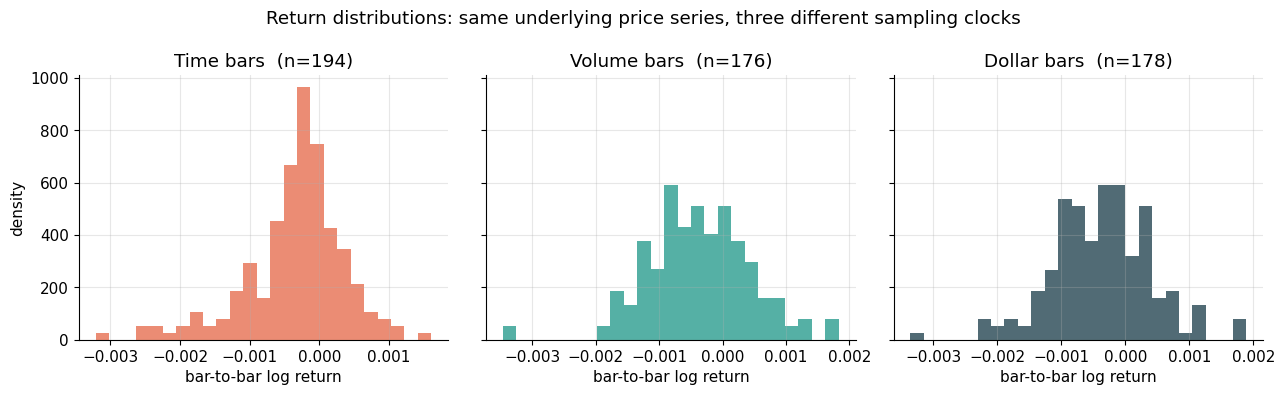

Recall: the Jarque-Bera test's null hypothesis is that the data is normally distributed.
A LOWER test statistic (higher p-value) means the sample looks MORE consistent with normality.

In this simulation, the sampling method closest to normal by this test is: dollar bars


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, r, name, color in zip(axes, [r_time, r_volume, r_dollar],
                                ['Time bars', 'Volume bars', 'Dollar bars'],
                                ['#e76f51', '#2a9d8f', '#264653']):
    ax.hist(r, bins=25, color=color, alpha=0.8, density=True)
    ax.set_title(f'{name}  (n={len(r)})')
    ax.set_xlabel('bar-to-bar log return')
axes[0].set_ylabel('density')
plt.suptitle('Return distributions: same underlying price series, three different sampling clocks')
plt.tight_layout()
plt.show()

print("Recall: the Jarque-Bera test's null hypothesis is that the data is normally distributed.")
print("A LOWER test statistic (higher p-value) means the sample looks MORE consistent with normality.\n")
best = summary['jarque_bera_stat'].idxmin()
print(f"In this simulation, the sampling method closest to normal by this test is: {best}")

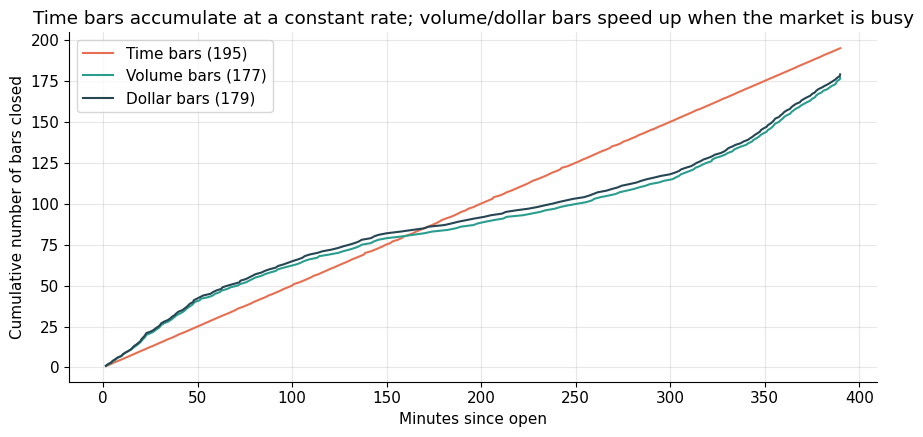

In [9]:
fig, ax = plt.subplots()
ax.plot(time_bars['t_end'],   np.arange(1, len(time_bars) + 1),   label=f'Time bars ({len(time_bars)})',   color='#e76f51')
ax.plot(volume_bars['t_end'], np.arange(1, len(volume_bars) + 1), label=f'Volume bars ({len(volume_bars)})', color='#2a9d8f')
ax.plot(dollar_bars['t_end'], np.arange(1, len(dollar_bars) + 1), label=f'Dollar bars ({len(dollar_bars)})', color='#264653')
ax.set_xlabel('Minutes since open')
ax.set_ylabel('Cumulative number of bars closed')
ax.set_title('Time bars accumulate at a constant rate; volume/dollar bars speed up when the market is busy')
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the result

The bottom chart makes the core idea of this notebook completely concrete: the **time-bar** line is a straight line, by construction — it does not care what the market is doing. The **volume-bar** and **dollar-bar** lines are visibly steeper near the open and close (matching the U-shaped intensity we built into the simulation) and flatter around midday: they are, quite literally, ticking faster when there is more information flowing through the market and slower when there is less. That is what "sampling in volume time instead of clock time" means in practice, not just in principle.

For the distributional comparison, report honestly whatever your own run of the notebook shows in the `summary` table — with only a few hundred bars from a single simulated day, the Jarque-Bera comparison is itself fairly noisy (see Exercise 2), and the point of this section is to show you *how* to run this comparison on your own data, not to claim a universal law from one simulated sample.

## 6. Limitations and pitfalls

- **Real tick data is messier.** It includes quotes as well as trades, often from multiple competing venues that need to be consolidated, and the direction (buy- or sell-initiated) of a trade is frequently *inferred* rather than directly known — commonly via the Lee-Ready algorithm, comparing the trade price to the prevailing quote midpoint — which introduces classification error absent from our simulation, where we generated the true sign ourselves.
- **Thresholds are hyperparameters, not physical constants.** There is no universally "correct" volume or dollar threshold — a reasonable choice for a large-cap stock is far too coarse for a small cap. In a real deployment, thresholds are typically re-estimated periodically (e.g., as a rolling multiple of recent average daily volume) so they keep pace with a stock's evolving activity level over months and years.
- **Volume and dollar bars are not "point-in-time" available in the same way time bars are.** You do not know a volume bar has closed until the threshold is actually hit — which happens at an unpredictable, data-dependent moment. This is a subtlety that matters for any live trading system, and is easy to overlook when working with historical data in a notebook.
- **Our tick simulator is still far simpler than real order flow.** In particular, trade arrivals within each minute are still (locally) Poisson, so they lack the self-exciting, "one trade triggers a cluster of others" clustering that real markets show — the subject of the Hawkes process in Notebook 18.

## 7. Exercises

**1. A sub-window benchmark (warm-up).**
Compute VWAP and TWAP for just the last 60 minutes of the trading day (`ticks[ticks['t'] >= 330]`), and compare both to the full-day values computed above. Which measure moved more, and does that make sense given how volume is distributed late in the day?

**2. Dollar bars vs. volume bars: when do they actually differ?**
In this notebook, dollar bars and volume bars behave very similarly, because the price barely moves over one simulated day. Modify `simulate_trading_day` to run over many days (you can concatenate several independent calls, each continuing from the previous day's closing price, and add a small daily drift), so the price trends meaningfully upward or downward over the full sample. Rebuild volume bars and dollar bars with fixed thresholds over this longer series, and compare how the number of bars produced per calendar day changes over time for each method. Which one stays more stable, and why does that match the motivation given in Section 3.3?

**3. Build an imbalance bar.**
A more advanced bar type, inspired by López de Prado's work, closes a bar not on a fixed volume or dollar threshold, but when the *cumulative signed* volume imbalance (using the true `sign` column from our simulation) deviates enough from what a running estimate of "expected" imbalance would predict. Design and implement a simplified version: maintain an exponentially-weighted moving average of the per-trade signed volume, and close a bar whenever the cumulative sum of `sign * size` since the last bar closed exceeds, in absolute value, a multiple of that moving average times the typical number of trades per bar. Compare the resulting bar count and return distribution to the fixed-threshold volume bars above. What kind of market conditions would make this adaptive approach most useful?